In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from ta.trend import SMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from bs4 import BeautifulSoup

In [ ]:
def fetch_coingecko_daily(days=90):
    url = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart"
    params = {
        "vs_currency": "usd",
        "days": days  # 1, 7, 14, 30, 90, 180, 365
    }

    response = requests.get(url, params=params)
    data = response.json()

    if "prices" not in data:
        raise ValueError("Missing 'prices' in API response. Full response:\n" + str(data))

    prices = data["prices"]
    df = pd.DataFrame(prices, columns=["timestamp", "price"])
    df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    df.set_index("timestamp", inplace=True)
    df["close"] = df["price"]
    df.drop(columns=["price"], inplace=True)
    return df

df = fetch_coingecko_daily(90)
df.tail()

,close
timestamp,
2025-05-30 05:03:30.717,106026.604381
2025-05-30 06:03:40.689,106137.022629
2025-05-30 07:03:21.808,105808.867272
2025-05-30 08:03:25.213,105110.098230
2025-05-30 09:13:07.000,105254.893326


In [ ]:
from ta.trend import SMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

def add_indicators(df):
    df["SMA_20"] = SMAIndicator(df["close"], window=20).sma_indicator()
    df["SMA_50"] = SMAIndicator(df["close"], window=50).sma_indicator()
    df["RSI"] = RSIIndicator(df["close"], window=14).rsi()
    df["MACD"] = MACD(df["close"]).macd_diff()
    bb = BollingerBands(df["close"])
    df["bb_bbm"] = bb.bollinger_mavg()
    df["bb_bbh"] = bb.bollinger_hband()
    df["bb_bbl"] = bb.bollinger_lband()
    df.dropna(inplace=True)
    return df

df = add_indicators(df)
df.tail()

,close,SMA_20,SMA_50,RSI,MACD,bb_bbm,bb_bbh,bb_bbl
timestamp,,,,,,,,
2025-05-30 05:03:30.717,106026.604381,106811.771296,107605.716755,36.728036,-18.793679,106811.771296,108932.408025,104691.134567
2025-05-30 06:03:40.689,106137.022629,106693.092329,107550.776689,38.946618,12.236853,106693.092329,108681.713302,104704.471356
2025-05-30 07:03:21.808,105808.867272,106549.372000,107488.150488,35.016869,15.056282,106549.372000,108348.315450,104750.428551
2025-05-30 08:03:25.213,105110.098230,106366.053684,107413.105060,28.436995,-23.640277,106366.053684,107954.791754,104777.315613
2025-05-30 09:13:07.000,105254.893326,106202.519313,107340.410688,31.317008,-32.441542,106202.519313,107518.322774,104886.715853


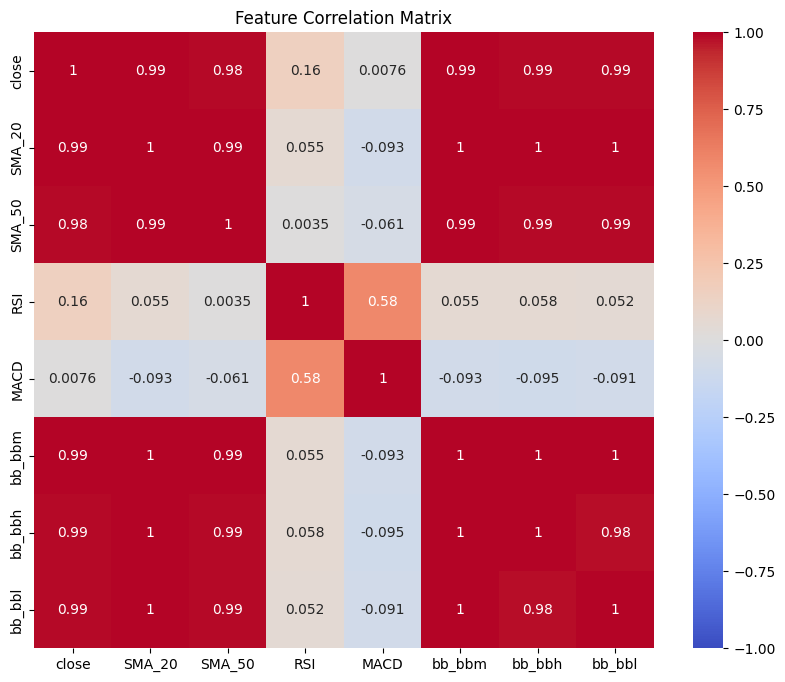

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[["close", "SMA_20", "SMA_50", "RSI", "MACD", "bb_bbm", "bb_bbh", "bb_bbl"]].corr(),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

features = ["close", "SMA_20", "SMA_50", "RSI", "MACD", "bb_bbm", "bb_bbh", "bb_bbl"]
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df[features])

def create_sequences(data, seq_len=10):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled)

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer="adam", loss="mean_squared_error")
model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.0113 - val_loss: 0.0042
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.0025 - val_loss: 4.2008e-04
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0019 - val_loss: 3.5786e-04
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0018 - val_loss: 4.2811e-04
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0017 - val_loss: 3.6636e-04
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0014 - val_loss: 0.0028
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0014 - val_loss: 3.3761e-04
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 9/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0015 - val_loss: 4.4735e-04
Epoch 10/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0014 - val_loss: 4.4426e-04


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step


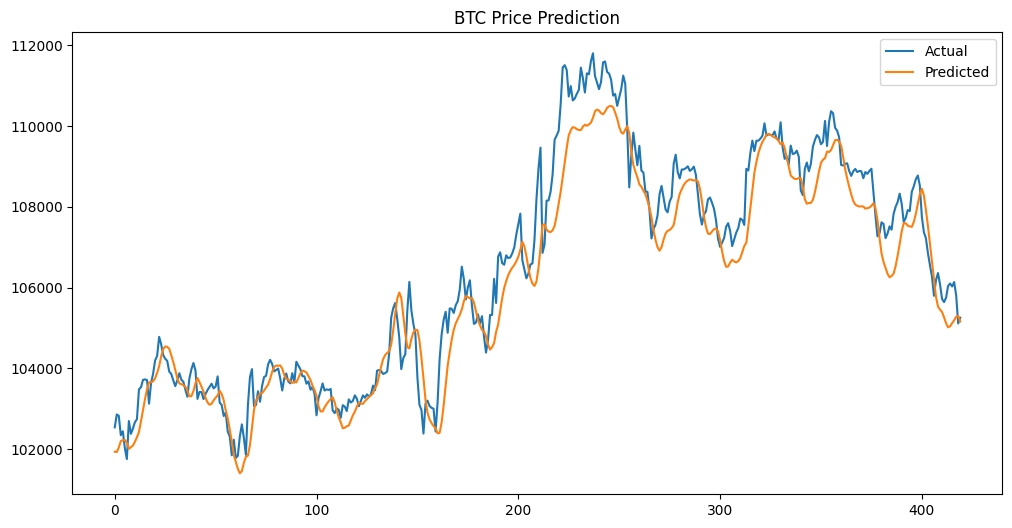

RMSE: 780.5650488587711
MAE: 604.7813536965728
R²: 0.9190997425097601


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

predicted_prices = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1)
)[:, 0]

actual_prices = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), len(features)-1))], axis=1)
)[:, 0]

plt.figure(figsize=(12, 6))
plt.plot(actual_prices, label='Actual')
plt.plot(predicted_prices, label='Predicted')
plt.title("BTC Price Prediction")
plt.legend()
plt.show()

print("RMSE:", np.sqrt(mean_squared_error(actual_prices, predicted_prices)))
print("MAE:", mean_absolute_error(actual_prices, predicted_prices))
print("R²:", r2_score(actual_prices, predicted_prices))

In [ ]:
def directional_accuracy(actual, predicted):
    return np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted)))

print("Directional Accuracy:", directional_accuracy(actual_prices, predicted_prices))

Directional Accuracy: 0.5035799522673031


In [ ]:
def backtest_lstm(data, features, sequence_length=10, train_size=0.8, step_size=50):
    """
    Run walk-forward backtesting on time-series LSTM model.

    Parameters:
    - data: Scaled dataset (NumPy)
    - features: List of feature names
    - sequence_length: LSTM sequence input size
    - train_size: % of each window used for training
    - step_size: How many timesteps to move forward in each iteration
    """
    all_actual = []
    all_predicted = []

    for start in range(0, len(data) - sequence_length - step_size, step_size):
        end = start + step_size + sequence_length
        window_data = data[start:end]

        # Skip short windows
        if len(window_data) < sequence_length + 2:
            continue

        # Create sequences
        X, y = [], []
        for i in range(sequence_length, len(window_data)):
            X.append(window_data[i-sequence_length:i])
            y.append(window_data[i, 0])  # target is 'close'

        X, y = np.array(X), np.array(y)
        split = int(train_size * len(X))
        X_train, X_test = X[:split], X[split:]
        y_train, y_test = y[:split], y[split:]

        # Define & train model
        model = Sequential([
            LSTM(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
            Dropout(0.2),
            LSTM(30),
            Dropout(0.2),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")
        model.fit(X_train, y_train, epochs=5, batch_size=16, verbose=0)

        y_pred = model.predict(X_test)

        # Inverse scale
        y_test_inv = scaler.inverse_transform(
            np.concatenate([y_test.reshape(-1,1), np.zeros((len(y_test), len(features)-1))], axis=1)
        )[:, 0]
        y_pred_inv = scaler.inverse_transform(
            np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1)
        )[:, 0]

        all_actual.extend(y_test_inv)
        all_predicted.extend(y_pred_inv)

    return np.array(all_actual), np.array(all_predicted)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


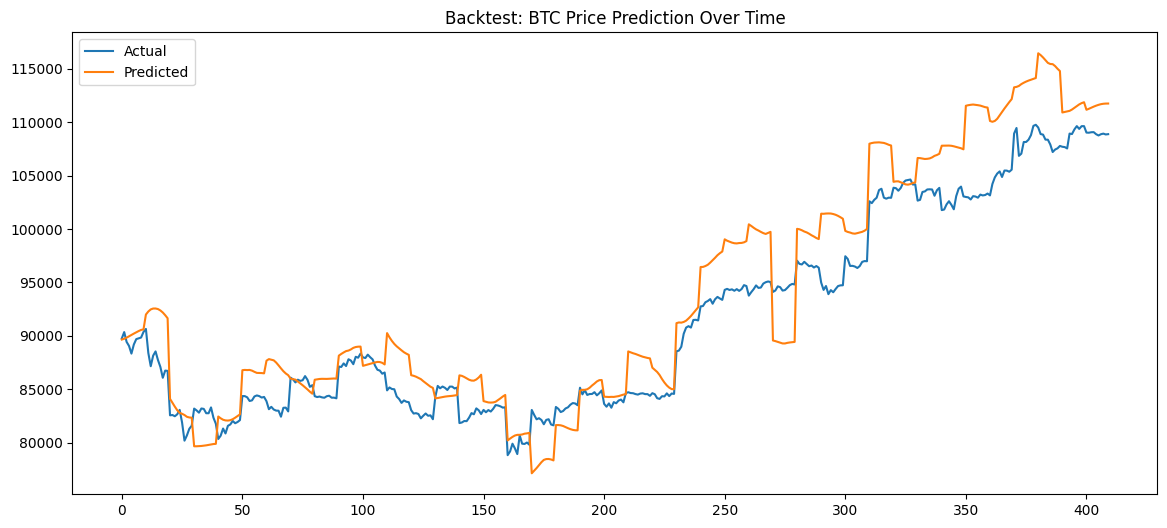

Backtest RMSE: 3737.8416623167923
Backtest MAE: 3068.767254469763
Backtest R²: 0.8363454776060744
Backtest Directional Accuracy: 0.5281173594132029


In [ ]:
actual_bt, predicted_bt = backtest_lstm(scaled, features, sequence_length=10, step_size=50)

# Plot
plt.figure(figsize=(14,6))
plt.plot(actual_bt, label="Actual")
plt.plot(predicted_bt, label="Predicted")
plt.title("Backtest: BTC Price Prediction Over Time")
plt.legend()
plt.show()

# Metrics
print("Backtest RMSE:", np.sqrt(mean_squared_error(actual_bt, predicted_bt)))
print("Backtest MAE:", mean_absolute_error(actual_bt, predicted_bt))
print("Backtest R²:", r2_score(actual_bt, predicted_bt))

# Directional Accuracy
def directional_accuracy(actual, predicted):
    return np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted)))

print("Backtest Directional Accuracy:", directional_accuracy(actual_bt, predicted_bt))

In [ ]:
def simulate_trading(actual, predicted, starting_cash=100_000, fee=0.001):
    """
    Simulate directional trading based on predicted BTC prices.
    You go long (buy BTC) if the model predicts the price will go up, and sell otherwise.

    Returns portfolio history and buy-hold benchmark.
    """
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Initialize
    cash = starting_cash
    btc = 0
    portfolio = []

    for i in range(1, len(predicted)):
        pred_dir = np.sign(predicted[i] - predicted[i-1])
        actual_price = actual[i]

        # Buy condition
        if pred_dir > 0 and cash > 0:
            btc = (cash * (1 - fee)) / actual_price
            cash = 0

        # Sell condition
        elif pred_dir < 0 and btc > 0:
            cash = btc * actual_price * (1 - fee)
            btc = 0

        # Record total value
        total = cash + btc * actual_price
        portfolio.append(total)

    # Buy & Hold benchmark
    bh_btc = (starting_cash * (1 - fee)) / actual[0]
    bh_value = bh_btc * actual[1:len(portfolio)+1]

    return np.array(portfolio), np.array(bh_value)

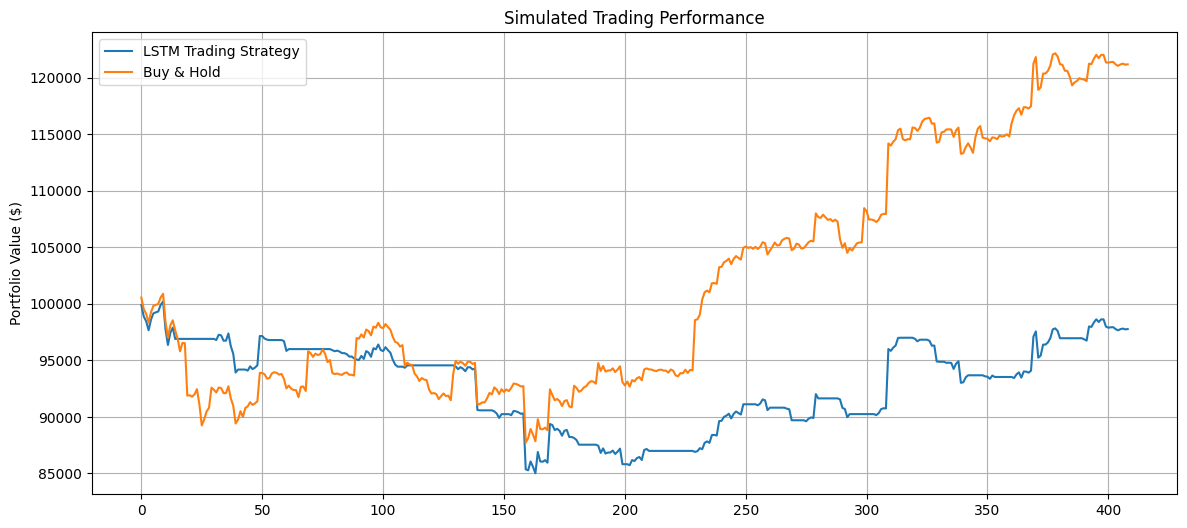

Final Value (LSTM Strategy): $97,773.51
Final Value (Buy & Hold):    $121,199.88
Outperformance:              $-23,426.38


In [ ]:
# Simulate trading
portfolio, buy_hold = simulate_trading(actual_bt, predicted_bt)

# Plot
plt.figure(figsize=(14,6))
plt.plot(portfolio, label="LSTM Trading Strategy")
plt.plot(buy_hold, label="Buy & Hold")
plt.title("Simulated Trading Performance")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()

# Performance comparison
print(f"Final Value (LSTM Strategy): ${portfolio[-1]:,.2f}")
print(f"Final Value (Buy & Hold):    ${buy_hold[-1]:,.2f}")
print(f"Outperformance:              ${portfolio[-1] - buy_hold[-1]:,.2f}")

In [ ]:
def simulate_threshold_trading(actual_prices, predicted_prices, threshold=0.002, starting_cash=100_000, fee=0.001):
    """
    Simulate trading based on predicted price changes (delta) with a directional threshold.

    Parameters:
    - threshold: Minimum percent change (e.g. 0.002 = 0.2%) to trigger a trade
    """
    cash = starting_cash
    btc = 0
    portfolio = []
    buy_points, sell_points = [], []

    for i in range(1, len(predicted_prices)):
        pred_change = predicted_prices[i] - predicted_prices[i - 1]
        pct_change = pred_change / predicted_prices[i - 1]
        actual_price = actual_prices[i]

        # Buy
        if pct_change > threshold and cash > 0:
            btc = (cash * (1 - fee)) / actual_price
            cash = 0
            buy_points.append(i)

        # Sell
        elif pct_change < -threshold and btc > 0:
            cash = btc * actual_price * (1 - fee)
            btc = 0
            sell_points.append(i)

        portfolio.append(cash + btc * actual_price)

    # Buy & Hold benchmark
    bh_btc = (starting_cash * (1 - fee)) / actual_prices[0]
    bh_value = bh_btc * np.array(actual_prices[1:len(portfolio)+1])

    return np.array(portfolio), bh_value, buy_points, sell_points

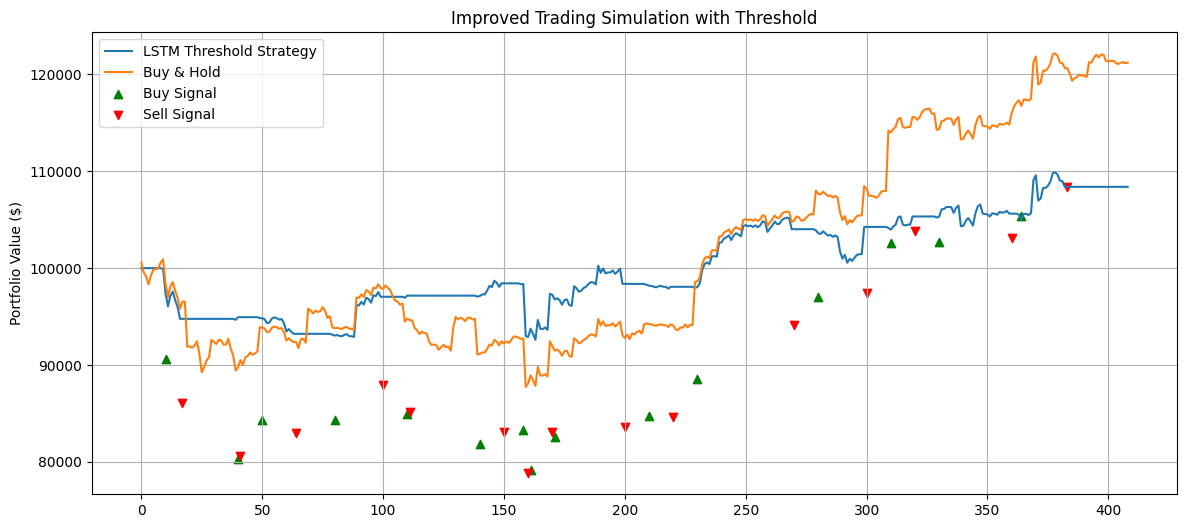

Final Value (Threshold Strategy): $108,390.95
Final Value (Buy & Hold):         $121,199.88
Outperformance:                   $-12,808.93


In [ ]:
# threshold = 0.2%
portfolio2, bh2, buys, sells = simulate_threshold_trading(actual_bt, predicted_bt, threshold=0.002)

plt.figure(figsize=(14,6))
plt.plot(portfolio2, label="LSTM Threshold Strategy")
plt.plot(bh2, label="Buy & Hold")
plt.scatter(buys, np.array(actual_bt)[buys], color='green', marker='^', label='Buy Signal')
plt.scatter(sells, np.array(actual_bt)[sells], color='red', marker='v', label='Sell Signal')
plt.title("Improved Trading Simulation with Threshold")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True)
plt.show()

# Final Results
print(f"Final Value (Threshold Strategy): ${portfolio2[-1]:,.2f}")
print(f"Final Value (Buy & Hold):         ${bh2[-1]:,.2f}")
print(f"Outperformance:                   ${portfolio2[-1] - bh2[-1]:,.2f}")

In [ ]:
def directional_accuracy(actual, predicted):
    return np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(predicted)))

print("Directional Accuracy:", directional_accuracy(actual_bt, predicted_bt))

Directional Accuracy: 0.5281173594132029


In [ ]:
def create_direction_labels(df, target_column="close", shift=1):
    """
    Create binary labels: 1 if price will go up, 0 otherwise.
    """
    df = df.copy()
    df["future_return"] = df[target_column].shift(-shift) - df[target_column]
    df["target"] = (df["future_return"] > 0).astype(int)
    df.dropna(inplace=True)
    return df

df_labeled = create_direction_labels(df)

In [ ]:
features = ["close", "SMA_20", "SMA_50", "RSI", "MACD", "bb_bbm", "bb_bbh", "bb_bbl"]
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df_labeled[features])
targets = df_labeled["target"].values

def create_sequences(X, y, seq_len=10):
    X_seq, y_seq = [], []
    for i in range(seq_len, len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X, y = create_sequences(scaled_features, targets, seq_len=10)

In [ ]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4968 - loss: 0.6955 - val_accuracy: 0.5333 - val_loss: 0.6925
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4778 - loss: 0.6944 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4945 - loss: 0.6940 - val_accuracy: 0.5333 - val_loss: 0.6910
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4871 - loss: 0.6944 - val_accuracy: 0.5333 - val_loss: 0.6926
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4858 - loss: 0.6942 - val_accuracy: 0.5333 - val_loss: 0.6923
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5038 - loss: 0.6935 - val_accuracy: 0.5333 - val_loss: 0.6911
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5116 - loss: 0.6937 - val_accuracy: 0.5333 - val_loss: 0.6928
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5035 - loss: 0.6932 - val_accuracy: 0.5333 - val_loss: 0.

In [ ]:
y_pred_probs = model.predict(X_test).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

from sklearn.metrics import accuracy_score, confusion_matrix

print("Direction Prediction Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Direction Prediction Accuracy: 0.5333333333333333
Confusion Matrix:
 [[  0 196]
 [  0 224]]


In [ ]:
import numpy as np
print("Class balance:", np.bincount(y))

Class balance: [1020 1079]


In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_test, y_test), class_weight=class_weights_dict)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4885 - loss: 0.6942 - val_accuracy: 0.5333 - val_loss: 0.6915
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4889 - loss: 0.6944 - val_accuracy: 0.5333 - val_loss: 0.6921
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5129 - loss: 0.6932 - val_accuracy: 0.4667 - val_loss: 0.6936
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.4934 - loss: 0.6937 - val_accuracy: 0.5333 - val_loss: 0.6920
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.4991 - loss: 0.6932 - val_accuracy: 0.4714 - val_loss: 0.6933
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5010 - loss: 0.6937 - val_accuracy: 0.5333 - val_loss: 0.6921
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4945 - loss: 0.6937 - val_accuracy: 0.4857 - val_loss: 0.6932
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5194 - loss: 0.6931 - val_accuracy: 0.5333 - v

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       196
           1       0.53      1.00      0.70       224

    accuracy                           0.53       420
   macro avg       0.27      0.50      0.35       420
weighted avg       0.28      0.53      0.37       420



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_lr = df_labeled[["SMA_20", "SMA_50", "RSI", "MACD", "bb_bbm", "bb_bbh", "bb_bbl"]]
y_lr = df_labeled["target"]

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_lr, test_size=0.2, shuffle=False)

model_lr = LogisticRegression()
model_lr.fit(X_train_lr, y_train_lr)

y_pred_lr = model_lr.predict(X_test_lr)

print("Logistic Regression Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print(classification_report(y_test_lr, y_pred_lr))

Logistic Regression Accuracy: 0.5308056872037915
              precision    recall  f1-score   support

           0       0.48      0.12      0.19       196
           1       0.54      0.89      0.67       226

    accuracy                           0.53       422
   macro avg       0.51      0.50      0.43       422
weighted avg       0.51      0.53      0.45       422



In [ ]:
def fetch_recent_bitcoin_articles(max_results=10):
    query = "bitcoin_today"
    headers = {'User-Agent': 'Mozilla/5.0'}
    search_url = f"https://duckduckgo.com/html/?q={query}+site:news"

    response = requests.get(search_url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')

    articles = []
    for link in soup.find_all('a', class_='result__a', limit=max_results):
        title = link.get_text()
        url = link['href']
        articles.append({'title': title, 'url': url})

    return articles

bitcoin_articles = fetch_recent_bitcoin_articles()
for i, article in enumerate(bitcoin_articles, 1):
    print(f"{i}. {article['title']}\n   {article['url']}\n")

1. Bitcoin price: BTC to USD, chart & market stats - crypto.news
   //duckduckgo.com/l/?uddg=https%3A%2F%2Fcrypto.news%2Fprice%2Fbitcoin%2F&rut=0f888afab9dd6de0a55b90f062fe975f4a97cabd658387213816c0c3cdf9d224

2. News from Bitcoin - Ground News
   //duckduckgo.com/l/?uddg=https%3A%2F%2Fground.news%2Finterest%2Fbitcoin&rut=978976d85dbf83b8f9d9f871921685041123049ff9377610760a352f4eab73d6

3. Bitcoin hits new all-time high - Sherwood News
   //duckduckgo.com/l/?uddg=https%3A%2F%2Fsherwood.news%2Fcrypto%2Fbitcoin%2Dhits%2Dnew%2Dall%2Dtime%2Dhigh%2F&rut=2e94291d6e8117f8f8a60e4232b430cd15278b8b77a83044072f9045f21cca40

4. BTC Price Today Surges Near $86K Amid Tariff Relief
   //duckduckgo.com/l/?uddg=https%3A%2F%2Fcrypto%2Dfeed.news%2Fnews%2Fbitcoin%2Fbtc%2Dprice%2Dtoday%2Dsurges%2Dnear%2D86k%2Damid%2Dtariff%2Drelief%2F&rut=02793c457b66337f166a8e6a12a54e95bdd4fc3b847e5680384ec5d60c3fd8b0

5. Bitcoin reaches $75k, marking new ATH on the heels of US election
   //duckduckgo.com/l/?uddg=https%3